# Experiment: SML2010 Dataset


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge,RidgeCV
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV, KFold
from sklearn import preprocessing
from sklearn.model_selection import cross_val_score
from sklearn.utils import resample
import seaborn as sns
# Import types and functions implemented in C
import tracemalloc
from _tracemalloc import *
from _tracemalloc import _get_object_traceback, _get_traces


import torch
from torch.utils.data import Dataset,DataLoader
from torch import optim
import torch.nn as nn
import torch.nn.utils.prune as prune
import torch.nn.functional as F

import psutil, os, sys
import resource  # Built-in, no pip install needed
import gc
import multiprocessing
import threading

import random



In [56]:
# =============================================
# Global Training Parameters
# =============================================
# Change these values once to apply to all algorithms
TRAINING_CONFIG = {
    'batch_size': 256,
    'max_epochs': 1000,
    'early_stop_window': 50,
    'lr': 1e-4,
    'momentum': 0.95,
    'weight_decay': 1e-3,
    'seed': 7199,
}

# =============================================
# Global Network Architecture Parameters
# =============================================
# Input dimension (determined by dataset)
INPUT_DIM = 15      # Number of features in dataset

# Hidden layer dimensions (shared across all models)
HIDDEN_DIM1 = 32    # First hidden layer dimension
HIDDEN_DIM2 = 64   # Second hidden layer dimension
HIDDEN_DIM3 = 16    # Third hidden layer dimension

# Results directory for this gamma-median run
RESULTS_DIR = 'sml_results_calib40'
os.makedirs(RESULTS_DIR, exist_ok=True)


In [57]:
# Read header line to get column names
import re
with open('../../data/sml2010/NEW-DATA-1.T15.txt', 'r') as f:
    header_line = f.readline().strip()

# Extract column names from header (remove # and split by whitespace)
header_line = header_line.lstrip('#').strip()
column_names = re.split(r'\s+', header_line)

# Read data files with proper separator (multiple whitespaces) and skip header line
df1=pd.read_csv('../../data/sml2010/NEW-DATA-1.T15.txt', sep=r'\s+', skiprows=1, header=None, names=column_names)
df2=pd.read_csv('../../data/sml2010/NEW-DATA-2.T15.txt', sep=r'\s+', skiprows=1, header=None, names=column_names)
tt=len(df1)
df=pd.concat([df1,df2],ignore_index=True)
df=df.drop(columns=['1:Date','2:Time','3:Temperature_Comedor_Sensor','5:Weather_Temperature','19:Exterior_Entalpic_1','20:Exterior_Entalpic_2','21:Exterior_Entalpic_turbo','24:Day_Of_Week']) 
display(df.head())
print(df.shape)

,4:Temperature_Habitacion_Sensor,6:CO2_Comedor_Sensor,7:CO2_Habitacion_Sensor,8:Humedad_Comedor_Sensor,9:Humedad_Habitacion_Sensor,10:Lighting_Comedor_Sensor,11:Lighting_Habitacion_Sensor,12:Precipitacion,13:Meteo_Exterior_Crepusculo,14:Meteo_Exterior_Viento,15:Meteo_Exterior_Sol_Oest,16:Meteo_Exterior_Sol_Est,17:Meteo_Exterior_Sol_Sud,18:Meteo_Exterior_Piranometro,22:Temperature_Exterior_Sensor,23:Humedad_Exterior_Sensor
0,17.8275,216.560,221.920,39.9125,42.4150,81.6650,113.520,0.0,623.360,1.42625,9690.24,12604.20,95436.8,758.880,18.1150,48.3750
1,18.1207,219.947,220.363,39.9267,42.2453,81.7413,113.605,0.0,623.211,1.59200,11022.00,10787.20,95436.8,762.069,18.4147,47.8080
2,18.4367,219.403,218.933,39.7720,42.2267,81.4240,113.600,0.0,622.656,1.89133,13960.50,9669.63,95398.6,766.251,18.8533,47.4320
3,18.7513,218.613,217.045,39.7760,42.0987,81.5013,113.344,0.0,622.571,1.82800,18511.20,9648.13,95360.3,766.037,19.2907,47.0240
4,19.0414,217.714,216.080,39.7757,42.0686,81.4657,113.034,0.0,622.400,2.36071,26349.00,9208.32,95354.9,762.743,19.7400,45.4743


(4137, 16)


In [ ]:
x = df.iloc[:, 1:]
y = df.iloc[:, 0]

data = pd.concat([y, x], axis=1)

train, calibration = train_test_split(
    data[:tt], 
    test_size=0.4,
    shuffle=False 
)
test = data[tt:]
test = data[tt:]

train_y = train.iloc[:, 0].to_numpy()
train_x = train.iloc[:, 1:].to_numpy()

calibration_y = calibration.iloc[:, 0].to_numpy()
calibration_x = calibration.iloc[:, 1:].to_numpy()

test_y = test.iloc[:, 0].to_numpy()
test_x = test.iloc[:, 1:].to_numpy()

#x_scaler = preprocessing.MinMaxScaler()
x_scaler = preprocessing.StandardScaler()
train_x = x_scaler.fit_transform(train_x)  
calibration_x = x_scaler.transform(calibration_x)
test_x = x_scaler.transform(test_x)

train_x.shape, calibration_x.shape, test_x.shape

nntrain_x = torch.from_numpy(train_x).float()
nntrain_y = torch.squeeze(torch.from_numpy(train_y).float()) 
nntest_x= torch.from_numpy(test_x).float()
nntest_y = torch.squeeze(torch.from_numpy(test_y).float())


In [59]:
train.shape

(1658, 16)

In [60]:
# ── Per-layer median-distance heuristic for gamma ───────────────────────────
# For RFF with W ~ N(0, gamma^2 I), the kernel is exp(-gamma^2/2 * ||x-y||^2).
# Matching the median heuristic: gamma = 1 / sqrt(median_sqdist).
#
# Theoretically, each RFF layer should use a gamma matched to the distribution
# of ITS OWN inputs, not the original data. We provide:
#   - _compute_layer_gamma(X): helper that computes gamma from any data matrix X
#   - gamma_median: gamma for layer 1 (from train_x), also used by RF+Ridge
# Per-layer gammas for MLKM/ResKernelNet are computed inside their run functions
# using a random-init forward pass to approximate each layer's input distribution.

def _compute_layer_gamma(X_np):
    """Compute median-heuristic gamma from a numpy array X (n x d).
    Uses a subsample of up to 2000 rows to keep O(n^2) cost manageable."""
    X = X_np[:2000]  # subsample if large
    dists = np.sum((X[None,:,:] - X[:,None,:])**2, axis=-1)
    flat  = dists[np.triu_indices(len(X), k=1)]
    med_sq = float(np.median(flat))
    if med_sq < 1e-12:
        return 1.0  # fallback: data is degenerate
    return float(1.0 / np.sqrt(med_sq))

# Layer-1 gamma (from raw input features) — also used by RF+Ridge
gamma_median = _compute_layer_gamma(train_x)

print(f'gamma_l1 (from train_x, d={train_x.shape[1]}):  {gamma_median:.6f}')
print('Per-layer gammas for MLKM/ResKernelNet will be printed when each model runs.')


gamma_l1 (from train_x, d=15):  0.192788
Per-layer gammas for MLKM/ResKernelNet will be printed when each model runs.


In [61]:

print("NaNs in train_x:", np.isnan(train_x).any())
print("NaNs in calibration_x:", np.isnan(calibration_x).any())
print("NaNs in test_x:", np.isnan(test_x).any())

print("NaNs per column in train_x:", np.isnan(train_x).sum(axis=0))
print("NaNs per column in test_x:", np.isnan(test_x).sum(axis=0))
print("Rows in train_x with any NaN:", np.isnan(train_x).any(axis=1).sum())
print("Rows in test_x with any NaN:", np.isnan(test_x).any(axis=1).sum())


NaNs in train_x: False
NaNs in calibration_x: False
NaNs in test_x: False
NaNs per column in train_x: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
NaNs per column in test_x: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Rows in train_x with any NaN: 0
Rows in test_x with any NaN: 0


In [62]:

class mydataset(Dataset):
    def __init__(self, x, y):
        self._x = x
        self._y = y
        self._len = len(x)

    def __getitem__(self, item): 
        return self._x[item], self._y[item]

    def __len__(self):
        return self._len

In [63]:
GLOBAL_SEED = 7199   # or any integer you choose

def set_global_seed(seed: int):
    if seed is None:
        seed = GLOBAL_SEED
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
def measure_time(func, *args, **kwargs):
    """
    Measure wall-clock time of func(*args, **kwargs).
    Returns (result, runtime_in_seconds).
    """
    t0 = time.time()
    result = func(*args, **kwargs)
    t1 = time.time()
    return result, (t1 - t0)


# def measure_memory_cpu(func, *args, **kwargs):
#     """
#     Measure CPU memory during func() execution using a background polling thread.
#     Returns: (result, delta_mb, peak_mb)
#       - delta_mb: net RSS change (after - before). Can be negative if GC reclaims
#                   memory during execution, so treat as informational only.
#       - peak_mb:  peak RSS *increase* above baseline during execution (always >= 0).
#                   Captured via a 50ms polling thread — the reliable metric.
#     """
#     gc.collect()
#     if torch.cuda.is_available():
#         torch.cuda.empty_cache()

#     process = psutil.Process(os.getpid())
#     mem_before = process.memory_info().rss

#     peak_rss = [mem_before]
#     stop_event = threading.Event()

#     def _monitor():
#         while not stop_event.is_set():
#             try:
#                 cur = process.memory_info().rss
#                 if cur > peak_rss[0]:
#                     peak_rss[0] = cur
#             except Exception:
#                 pass
#             stop_event.wait(0.05)

#     monitor_thread = threading.Thread(target=_monitor, daemon=True)
#     monitor_thread.start()

#     result = func(*args, **kwargs)

#     mem_after = process.memory_info().rss
#     stop_event.set()
#     monitor_thread.join()

#     if mem_after > peak_rss[0]:
#         peak_rss[0] = mem_after

#     delta_mb = (mem_after - mem_before) / 1024**2
#     peak_mb  = (peak_rss[0] - mem_before) / 1024**2

#     return result, delta_mb, peak_mb


def _release_memory():
    gc.collect(); gc.collect(); gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    try: ctypes.CDLL("libc.so.6").malloc_trim(0)
    except Exception: pass


def measure_memory_cpu(func, *args, **kwargs):
    """Warm-up + measured run. Returns (result, delta_MB, peak_MB)."""
    _release_memory()
    try: func(*args, **kwargs)
    except Exception: pass
    _release_memory()

    proc = psutil.Process(os.getpid())
    mem_before = proc.memory_info().rss
    _hwm_factor = 1 if sys.platform == 'darwin' else 1024
    hwm_before = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    peak_rss = [mem_before]; stop_evt = threading.Event()
    def _monitor():
        while not stop_evt.is_set():
            try:
                cur = proc.memory_info().rss
                if cur > peak_rss[0]: peak_rss[0] = cur
            except Exception: pass
            stop_evt.wait(0.01)
    mon_thread = threading.Thread(target=_monitor, daemon=True)
    try: tracemalloc.stop()
    except Exception: pass
    tracemalloc.start(); mon_thread.start()
    result = func(*args, **kwargs)
    mem_after = proc.memory_info().rss
    hwm_after = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    stop_evt.set(); mon_thread.join()
    _, peak_bytes_tm = tracemalloc.get_traced_memory(); tracemalloc.stop()
    if mem_after > peak_rss[0]: peak_rss[0] = mem_after
    peak_rss_mb = max((peak_rss[0] - mem_before) / 1024**2, 0.0)
    peak_tm_mb  = peak_bytes_tm / 1024**2
    peak_hwm_mb = max((hwm_after - hwm_before) * _hwm_factor / 1024**2, 0.0)
    peak_mb = max(peak_rss_mb, peak_tm_mb, peak_hwm_mb)
    _release_memory()
    return result, (mem_after - mem_before) / 1024**2, peak_mb



def measure_memory_gpu(func, *args, **kwargs):
    """
    Measure peak GPU memory allocated during func().
    Returns: (result, peak_MB or None)
    """
    if not torch.cuda.is_available():
        return func(*args, **kwargs), None

    torch.cuda.reset_peak_memory_stats()

    result = func(*args, **kwargs)

    peak_bytes = torch.cuda.max_memory_allocated()
    peak_mb = peak_bytes / 1024**2

    return result, peak_mb


In [64]:

def conformal_split(net, X_cal, y_cal, X_te, y_te, alpha=0.05, device=None):
    """
    Standard split conformal prediction for regression.
    Returns (coverage, interval_length, q_hat).
    """
    net.eval()
    # Infer device from model parameters if not provided
    if device is None:
        try:
            device = next(net.parameters()).device
        except StopIteration:
            device = torch.device('cpu')

    with torch.no_grad():
        cp = net(torch.from_numpy(X_cal).float().to(device)).squeeze().cpu().numpy()
        tp = net(torch.from_numpy(X_te).float().to(device)).squeeze().cpu().numpy()

    scores = np.abs(y_cal - cp)
    m = len(scores)
    k = min(max(int(np.ceil((m + 1) * (1 - alpha))), 1), m)
    q = float(np.sort(scores)[k - 1])
    cov = float(np.mean((tp - q <= y_te) & (y_te <= tp + q)))
    return cov, 2 * q, q




def aci_conformal(net, X_cal, y_cal, X_te, y_te, alpha=0.05, gamma=0.01):
    """
    Adaptive Conformal Inference (ACI) 动态共形预测
    
    参数:
        net: 训练好的 PyTorch 模型
        X_cal, y_cal: 校准集特征和标签 (Numpy 数组)
        X_te, y_te: 测试集特征和标签 (Numpy 数组，需要按时间顺序排列)
        alpha: 目标错误率 (默认 0.05，即 95% 覆盖率)
        gamma: ACI 学习率 (控制对变化的敏感度，通常在 0.005 到 0.05 之间)
    """
    net.eval()
    with torch.no_grad():
        # 1. 预先计算校准集的残差 (Calibration Scores)
        cp = net(torch.from_numpy(X_cal).float()).squeeze().numpy()
        cal_scores = np.abs(y_cal - cp)
        
        # 2. 预先计算测试集的点预测 (Point Predictions)
        tp = net(torch.from_numpy(X_te).float()).squeeze().numpy()
    
    m = len(cal_scores)
    sorted_scores = np.sort(cal_scores)
    
    # 初始化 ACI 变量
    alpha_t = alpha  # 动态调整的 alpha，初始值设为目标 alpha
    coverages = []   # 记录每一步是否覆盖成功
    intervals = []   # 记录每一步的上下界
    
    # 3. 在线预测与动态更新 (Online Prediction & Update)
    for i in range(len(X_te)):
        # 确保 alpha_t 在合法范围内 (避免超过 0 和 1 导致分位数索引越界)
        alpha_t = np.clip(alpha_t, 0.001, 0.999)
        
        # 计算当前步的动态分位数
        k = min(max(int(np.ceil((m + 1) * (1 - alpha_t))), 1), m)
        q_t = float(sorted_scores[k - 1])
        
        # 生成当前步的预测区间
        y_pred = tp[i]
        lower_bound = y_pred - q_t
        upper_bound = y_pred + q_t
        intervals.append((lower_bound, upper_bound))
        
        # 观察真实值，计算是否覆盖 (Covered: 1, Missed: 0)
        y_true = y_te[i]
        covered = 1 if (lower_bound <= y_true <= upper_bound) else 0
        coverages.append(covered)
        
        # ACI 核心更新逻辑
        # 如果 covered=0，alpha_t 会变小 (区间变宽)
        # 如果 covered=1，alpha_t 会稍微变大 (区间变紧)
        alpha_t = alpha_t + gamma * (covered - (1 - alpha))
        
    final_coverage = np.mean(coverages)
    
    return final_coverage, intervals, coverages

### Random Feature

In [65]:
def sample_1d(pdf, gamma):
    if pdf=='G':
        w=torch.randn(1)*gamma
        return w
    elif pdf=='L':
        w=torch.distributions.laplace.Laplace(torch.tensor([0.0]), torch.tensor([1.0])).sample()*gamma
        return w
    elif pdf=='C':
        w=torch.distributions.cauchy.Cauchy(torch.tensor([0.0]), torch.tensor([1.0])).sample()*gamma
        return w
    
def sample(pdf, gamma, d):
    return torch.tensor([sample_1d(pdf, gamma) for _ in range(d)])

class RandomFourierFeature:
    """Random Fourier Feature
    Parameters
    ----------
    d : int
        Input space dimension
    D : int
        Feature space dimension
    W : shape (D,d)
    b : shape (D)
    kernel : char
        Kernel to use; 'G', 'L', or 'C'
    gamma : float
        pdf parameter
    """

    def __init__(self, d, D, W=None, b=None, kernel='G', gamma=1):

        self.d = d
        self.D = D
        self.gamma = gamma

        kernel = kernel.upper()
        if kernel not in ['G', 'L', 'C']:
            raise Exception('Invalid Kernel')
        self.kernel = kernel

        if W is None or b is None:
            self.create()
        else:
            self.__load(W, b)

    def __load(self, W, b):
        """Load from existing Arrays"""

        self.W = W.reshape([self.D, self.d])
        self.b = b
    

    def create(self):
        """Create a d->D fourier random feature"""

        self.b = torch.rand(self.D)*2*torch.pi
        self.W = sample(self.kernel, self.gamma, self.d*self.D).reshape(self.D,self.d)

    def transform(self, x):
        """Transform a vector using this feature
        Parameters
        ----------
        x : (shape=(n,d))
            to transform; must be single dimension vector
        Returns
        -------
        x : (shape=(n,D))
            Feature space transformation of x
        """
        #print(self.W.shape,self.b.reshape(-1,1).shape,x.shape)
        #print((self.W @ x.T).shape)
       
        result=torch.sqrt(torch.tensor([2.0/self.D])) * torch.cos( self.W @ x.T  + (self.b.reshape(-1,1) @ torch.ones(len(x)).reshape(1,-1))) 
        #print(result.T.shape)
        return result.T

In [86]:
def run_rf_ridge(train_x, train_y, test_x, test_y,
                 calibration_x, calibration_y,
                 D=500, gamma=None, seed=7199):
    """
    Train RF + Ridge and return (train_mse, test_mse).
    No timing or memory in here.
    """
    g = gamma if gamma is not None else gamma_median
    set_global_seed(seed)
    rff = RandomFourierFeature(d=train_x.shape[1], D=D,
                               kernel='G', gamma=g)

    total_x = np.vstack((train_x, calibration_x))
    total_y = np.hstack((train_y, calibration_y))

    # Random Fourier Features
    total_feature = rff.transform(total_x)
    test_feature  = rff.transform(test_x)

    # Ridge + CV
    model = Ridge()
    param_grid = {'alpha': [1e-4,1e-3,1e-2,1e-1,1]}
    kf = KFold(n_splits=5, shuffle=True)

    grid_search = GridSearchCV(model, param_grid, cv=kf)
    grid_search.fit(total_feature, total_y)

    best_model = grid_search.best_estimator_
    rf_pred_total = best_model.predict(total_feature)
    rf_pred_test  = best_model.predict(test_feature)

    train_mse = mean_squared_error(total_y, rf_pred_total)
    test_mse  = mean_squared_error(test_y, rf_pred_test)
    return train_mse, test_mse


def rf_core():
    return run_rf_ridge(train_x, train_y, test_x, test_y,
                        calibration_x, calibration_y,
                        D=64, gamma=0.4, seed=7199)

# Clear memory before measurement
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

(rf_result, rf_delta_cpu_mb, rf_peak_cpu_mb), rf_time = measure_time(
    lambda: measure_memory_cpu(rf_core)
)

rf_train_mse, rf_test_mse = rf_result

print("RF train MSE:", rf_train_mse)
print("RF test MSE:",  rf_test_mse)
print("RF runtime (s):", rf_time)
print("RF CPU Δ memory (MB):", rf_delta_cpu_mb)
print("RF CPU peak (MB):", rf_peak_cpu_mb)


/var/folders/z7/p968ccvd4d9c27v5n0y0qbyw0000gn/T/ipykernel_4150/462636501.py:74: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  result=torch.sqrt(torch.tensor([2.0/self.D])) * torch.cos( self.W @ x.T  + (self.b.reshape(-1,1) @ torch.ones(len(x)).reshape(1,-1)))
/var/folders/z7/p968ccvd4d9c27v5n0y0qbyw0000gn/T/ipykernel_4150/462636501.py:74: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  result=torch.sqrt(torch.tensor([2.0/self.D])) * torch.cos( self.W @ x.T  + (self.b.reshape(-1,1) @ torch.ones(len(x)).reshape(1,-1)))


RF train MSE: 0.879525246152225
RF test MSE: 5.26417308077329
RF runtime (s): 1.8307228088378906
RF CPU Δ memory (MB): 0.484375
RF CPU peak (MB): 1.8592844009399414


## 1. DNN

In [67]:
class Net(nn.Module):
    def __init__(self):
        super(Net,self).__init__()
        self.fc1 = nn.Linear(INPUT_DIM, HIDDEN_DIM1)
        self.fc2 = nn.Linear(HIDDEN_DIM1, HIDDEN_DIM2)
        self.fc3 = nn.Linear(HIDDEN_DIM2, HIDDEN_DIM3)
        self.fc4 = nn.Linear(HIDDEN_DIM3, 1)
    def forward(self,x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.fc4(x)





#initialize
def init_weights(m):
    if type(m) == nn.Conv2d:
        torch.nn.init.normal_(m.weight,mean=0,std=0.5)
    if type(m) == nn.Linear:
        torch.nn.init.uniform_(m.weight,a=0,b=0.1)
        m.bias.data.fill_(0)

def run_dnn(train_x, train_y, test_x, test_y,
            batch_size=256,
            max_epochs=1000,
            early_stop_window=50,
            lr=1e-4,
            momentum=0.9,
            weight_decay=1e-2,
            device=None,
            verbose=False,
            seed=7199):
    """
    Train the DNN and return (train_mse, test_mse, num_epochs_run).
    No timing or memory measurement inside.
    """

    # reproducibility
    set_global_seed(seed)

    # choose device
    if device is None:
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # numpy -> tensors
    nntrain_x = torch.from_numpy(train_x).float()
    nntrain_y = torch.from_numpy(train_y).float().squeeze()
    # nntest_x  = torch.from_numpy(test_x).float()
    # nntest_y  = torch.from_numpy(test_y).float().squeeze()

    train_loader = DataLoader(mydataset(nntrain_x, nntrain_y),
                              batch_size=batch_size, shuffle=True)
    # test_loader  = DataLoader(mydataset(nntest_x, nntest_y),
    #                           batch_size=batch_size, shuffle=False)

    # model, loss, optimizer
    net = Net().to(device)
    net.apply(init_weights)

    criterion = nn.MSELoss()
    optimizer = optim.SGD(net.parameters(),
                          lr=lr,
                          momentum=momentum,
                          weight_decay=weight_decay)

    dnn_trainloss = []
    dnn_testloss  = []

    for epoch in range(max_epochs):
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            y_pred = net(x).squeeze()
            train_loss = criterion(y_pred, y)
            train_loss.backward()
            optimizer.step()

        # evaluate full train & test MSE (like your original code)
        net.eval()
        with torch.no_grad():
            # train MSE
            x0 = torch.from_numpy(train_x).float().to(device)
            pred_train = net(x0).squeeze().cpu().numpy()
            train_mse = mean_squared_error(train_y, pred_train)
            dnn_trainloss.append(train_mse)

            # test MSE
            x1 = torch.from_numpy(test_x).float().to(device)
            pred_test = net(x1).squeeze().cpu().numpy()
            test_mse = mean_squared_error(test_y, pred_test)
            dnn_testloss.append(test_mse)

        # early stopping: same idea as your code
        if epoch > early_stop_window:
            if float(dnn_trainloss[-1]) > max(dnn_trainloss[-early_stop_window:-1]):
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

        if verbose and epoch % 50 == 0:
            print(f"epoch {epoch:4d}  train MSE: {dnn_trainloss[-1]:.6f}  "
                  f"test MSE: {dnn_testloss[-1]:.6f}")

    num_epochs_run = len(dnn_trainloss)
    final_train_mse = dnn_trainloss[-1]
    final_test_mse  = dnn_testloss[-1]

    # Return training history and model for plotting and conformal prediction
    return final_train_mse, final_test_mse, num_epochs_run, net, optimizer, dnn_trainloss, dnn_testloss, device


In [68]:
def dnn_core():
    return run_dnn(train_x, train_y, test_x, test_y, **TRAINING_CONFIG)

# Clear memory before measurement
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# GPU wrapper inside, CPU wrapper around it, then time
((dnn_result, dnn_peak_gpu_mb), dnn_delta_cpu_mb, dnn_peak_cpu_mb), dnn_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(dnn_core)
    )
)


dnn_train_mse, dnn_test_mse, dnn_epochs, dnn_net, dnn_optimizer, dnn_trainloss, dnn_testloss, dnn_device = dnn_result

print("DNN train MSE:", dnn_train_mse)
print("DNN test MSE:",  dnn_test_mse)
print("DNN time:", dnn_time)
print("DNN peak GPU (MB):", dnn_peak_gpu_mb)
print("DNN CPU Δ (MB):", dnn_delta_cpu_mb)
print("DNN CPU peak (MB):", dnn_peak_cpu_mb)


DNN train MSE: 0.27444424657118727
DNN test MSE: 3.2456849672746517
DNN time: 21.25071096420288
DNN peak GPU (MB): None
DNN CPU Δ (MB): -412.03125
DNN CPU peak (MB): 0.37118053436279297


## 2. Resnet

In [69]:
class ResidualBlock(nn.Module):
    def __init__(self,infeatures,outfeatures):
        super(ResidualBlock,self).__init__()
        self.infeatures = infeatures
        self.outfeatures = outfeatures
        self.fc1 = nn.Linear(infeatures,outfeatures)
        self.fc2 = nn.Linear(outfeatures,outfeatures)
        self.skip = nn.Identity() if infeatures == outfeatures else nn.Linear(infeatures, outfeatures)

    
    def forward(self, x):
        identity = self.skip(x)
        y = F.relu(self.fc1(x))
        y = self.fc2(y)
        return identity + y


class ResNet(nn.Module): 
    def __init__(self):
        super(ResNet, self).__init__()
        self.rblock1 = ResidualBlock(INPUT_DIM, HIDDEN_DIM1)
        self.rblock2 = ResidualBlock(HIDDEN_DIM1, HIDDEN_DIM2)
        self.rblock3 = ResidualBlock(HIDDEN_DIM2, HIDDEN_DIM3)
        self.fc4 = nn.Linear(HIDDEN_DIM3, 1)
    
 
    def forward(self, x):
        x = self.rblock1(x)
        x = self.rblock2(x)
        x = self.rblock3(x)
        return self.fc4(x)

#initialize
def init_weights(m):
    if type(m) == nn.Conv2d:
        torch.nn.init.normal_(m.weight,mean=0,std=0.5)
    if type(m) == nn.Linear:
        torch.nn.init.uniform_(m.weight,a=-0.1,b=0.1)
        m.bias.data.fill_(0)

In [70]:
def run_resnet(train_x, train_y, test_x, test_y,
               batch_size=256,
               max_epochs=1000,
               early_stop_window=50,
               lr=1e-4,
               momentum=0.9,
               weight_decay=1e-2,
               device=None,
               verbose=False,
               seed=7199):
    """
    Train a ResNet on tabular input and return:
        (train_mse, test_mse, num_epochs_run)
    No timing or memory measurements inside.
    """

    # ========================
    # 1. Reproducibility
    # ========================
    set_global_seed(seed)

    # Determine device
    if device is None:
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # ========================
    # 2. Convert NumPy → Tensors
    # ========================
    nntrain_x = torch.from_numpy(train_x).float()
    nntrain_y = torch.from_numpy(train_y).float().squeeze()
    # nntest_x  = torch.from_numpy(test_x).float()
    # nntest_y  = torch.from_numpy(test_y).float().squeeze()

    train_loader = DataLoader(
        mydataset(nntrain_x, nntrain_y),
        batch_size=batch_size, shuffle=True
    )

    # test_loader = DataLoader(
    #     mydataset(nntest_x, nntest_y),
    #     batch_size=batch_size, shuffle=False
    # )

    # ========================
    # 3. Model, Loss, Optimizer
    # ========================
    net = ResNet().to(device)
    net.apply(init_weights)      # keep your initialization

    criterion = nn.MSELoss()

    optimizer = optim.SGD(
        net.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay
    )

    # ========================
    # 4. Training Loop
    # ========================
    res_trainloss = []
    res_testloss  = []
    for epoch in range(max_epochs):

        # ---- Training ----
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            y_pred = net(x).squeeze()
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()

        # ---- Evaluation ----
        net.eval()
        with torch.no_grad():
            # full train MSE
            x0 = torch.from_numpy(train_x).float().to(device)
            pred_train = net(x0).squeeze().cpu().numpy()
            train_mse = mean_squared_error(train_y, pred_train)
            res_trainloss.append(train_mse)

            # full test MSE
            x1 = torch.from_numpy(test_x).float().to(device)
            pred_test = net(x1).squeeze().cpu().numpy()
            test_mse = mean_squared_error(test_y, pred_test)
            res_testloss.append(test_mse)

        # ---- Early Skipping ----
        if epoch > early_stop_window:
            if res_trainloss[-1] > max(res_trainloss[-early_stop_window:-1]):
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

        # ---- Optional Printing ----
        if verbose and epoch % 50 == 0:
            print(f"""epoch {epoch}
                Train MSE: {train_mse}
                Test  MSE: {test_mse}
            """)

    # final metrics
    num_epochs_run = len(res_trainloss)
    final_train_mse = res_trainloss[-1]
    final_test_mse  = res_testloss[-1]
    
    # Return training history and model for plotting and conformal prediction
    return final_train_mse, final_test_mse, num_epochs_run, net, optimizer, res_trainloss, res_testloss, device


In [71]:
def resnet_core():
    return run_resnet(train_x, train_y, test_x, test_y, **TRAINING_CONFIG)

# Clear memory before measurement
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

((res_result, res_peak_gpu), res_delta_cpu, res_peak_cpu), res_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(resnet_core)
    )
)

res_train_mse, res_test_mse, res_epochs, res_net, res_optimizer, res_trainloss, res_testloss, res_device = res_result

print("ResNet Train MSE:", res_train_mse)
print("ResNet Test  MSE:", res_test_mse)
print("ResNet Epochs:", res_epochs)
print("ResNet Time:", res_time)
print("ResNet CPU ΔMB:", res_delta_cpu)
print("ResNet CPU peak (MB):", res_peak_cpu)
print("ResNet GPU peak MB:", res_peak_gpu)



ResNet Train MSE: 0.17643285571286818
ResNet Test  MSE: 3.6953545010015945
ResNet Epochs: 1000
ResNet Time: 25.796560764312744
ResNet CPU ΔMB: -18.546875
ResNet CPU peak (MB): 0.39064598083496094
ResNet GPU peak MB: None


## 2.5 DKL (NN feature extractor + GP)


In [72]:
import gpytorch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 1) feature extractor
class DKLFeatureExtractor(torch.nn.Module):
    def __init__(self, in_dim=INPUT_DIM):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(in_dim, HIDDEN_DIM1),
            torch.nn.ReLU(),
            torch.nn.Linear(HIDDEN_DIM1, HIDDEN_DIM2),
            torch.nn.ReLU(),
            torch.nn.Linear(HIDDEN_DIM2, HIDDEN_DIM3),
            torch.nn.ReLU(),
            torch.nn.Linear(HIDDEN_DIM3, 2),  
        )
    def forward(self, x):
        return self.net(x)

# 2) DKL model = ExactGP + feature extractor
class DKLExactGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, feature_extractor):
        super().__init__(train_x, train_y, likelihood)
        self.feature_extractor = feature_extractor
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())
        
    def forward(self, x):
        z = self.feature_extractor(x)
        mean_x = self.mean_module(z)
        covar_x = self.covar_module(z)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


def run_dkl(train_x, train_y, test_x, test_y, training_iter=300, seed=7199):
    """Train DKL and return (train_mse, test_mse)"""
    set_global_seed(seed)
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    # Convert to tensors
    train_x_t = torch.from_numpy(train_x).float().to(device)
    train_y_t = torch.from_numpy(train_y).float().squeeze().to(device)
    test_x_t = torch.from_numpy(test_x).float().to(device)
    
    # Initialize model
    dkl_likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
    feat = DKLFeatureExtractor(in_dim=train_x_t.shape[1]).to(device)
    dkl_model = DKLExactGP(train_x_t, train_y_t, dkl_likelihood, feat).to(device)
    
    # Train
    dkl_model.train()
    dkl_likelihood.train()
    
    optimizer = torch.optim.Adam([
        {'params': dkl_model.feature_extractor.parameters(), 'lr': 1e-3},
        {'params': dkl_model.covar_module.parameters()},
        {'params': dkl_model.mean_module.parameters()},
        {'params': dkl_likelihood.parameters()},
    ], lr=0.05)
    
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(dkl_likelihood, dkl_model)
    
    for i in range(training_iter):
        optimizer.zero_grad()
        output = dkl_model(train_x_t)
        loss = -mll(output, train_y_t)
        loss.backward()
        optimizer.step()
    
    # Eval
    dkl_model.eval()
    dkl_likelihood.eval()
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred_train = dkl_likelihood(dkl_model(train_x_t)).mean
        pred_test = dkl_likelihood(dkl_model(test_x_t)).mean
    
    train_mse = mean_squared_error(train_y, pred_train.detach().cpu().numpy())
    test_mse = mean_squared_error(test_y, pred_test.detach().cpu().numpy())
    
    return train_mse, test_mse


def dkl_core():
    return run_dkl(train_x, train_y, test_x, test_y)

# Clear memory before measurement
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Measure with wrappers
((dkl_result, dkl_peak_gpu), dkl_delta_cpu, dkl_peak_cpu), dkl_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(dkl_core)
    )
)

dkl_train_mse, dkl_test_mse = dkl_result

print("DKL Train MSE:", dkl_train_mse)
print("DKL Test  MSE:", dkl_test_mse)
print("DKL Time (s):", dkl_time)
print("DKL CPU Δ (MB):", dkl_delta_cpu)
print("DKL CPU peak (MB):", dkl_peak_cpu)
print("DKL GPU peak (MB):", dkl_peak_gpu)


/Users/wanghd/Desktop/Research/Dai/Multi_layer_kernel_machines/Multi-Layer-Kernel-Machine/venv/lib/python3.13/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/wanghd/Desktop/Research/Dai/Multi_layer_kernel_machines/Multi-Layer-Kernel-Machine/venv/lib/python3.13/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


DKL Train MSE: 0.09328911640887465
DKL Test  MSE: 4.564766681139044
DKL Time (s): 16.026830196380615
DKL CPU Δ (MB): -3.078125
DKL CPU peak (MB): 0.3075876235961914
DKL GPU peak (MB): None


## 2.6 DGP baseline（Deep Gaussian Process）

In [73]:
# ----- DGP building blocks -----
class DGPLayer(gpytorch.models.deep_gps.DeepGPLayer):
    def __init__(self, input_dims, output_dims, inducing_points):
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            inducing_points.size(0)
        )
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self,
            inducing_points,
            variational_distribution,
            learn_inducing_locations=True
        )
        super().__init__(variational_strategy, input_dims, output_dims)
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


def run_dgp(train_x, train_y, test_x, test_y, 
            training_iter=1000, batch_size=256, num_inducing=128, hidden_dim=5, seed=7199):
    """Train Deep GP and return (train_mse, test_mse)"""
    set_global_seed(seed)
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    # Convert to tensors
    train_x_t = torch.from_numpy(train_x).float().to(device)
    train_y_t = torch.from_numpy(train_y).float().squeeze().to(device)
    test_x_t = torch.from_numpy(test_x).float().to(device)
    
    # Build model (inline TwoLayerDGP to avoid global dependency)
    class TwoLayerDGP(gpytorch.models.deep_gps.DeepGP):
        def __init__(self, train_x_t, num_inducing, hidden_dim):
            super().__init__()
            inducing_1 = train_x_t[torch.randperm(train_x_t.size(0))[:num_inducing]]
            inducing_2 = torch.randn(num_inducing, hidden_dim).to(device)

            self.hidden_layer = DGPLayer(
                input_dims=train_x_t.shape[1],
                output_dims=hidden_dim,
                inducing_points=inducing_1
            )
            self.output_layer = DGPLayer(
                input_dims=hidden_dim,
                output_dims=None,
                inducing_points=inducing_2
            )
            self.likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)

        def forward(self, inputs):
            hidden_rep = self.hidden_layer(inputs)
            output = self.output_layer(hidden_rep)
            return output

        def predict(self, x):
            self.eval()
            self.likelihood.eval()
            with torch.no_grad(), gpytorch.settings.num_likelihood_samples(16):
                preds = self.likelihood(self(x))
                return preds.mean.mean(dim=0)
    
    dgp_model = TwoLayerDGP(train_x_t, num_inducing, hidden_dim).to(device)
    dgp_model.train()
    dgp_model.likelihood.train()
    
    optimizer = torch.optim.Adam(dgp_model.parameters(), lr=0.01)
    elbo = gpytorch.mlls.DeepApproximateMLL(
        gpytorch.mlls.VariationalELBO(dgp_model.likelihood, dgp_model, num_data=train_x_t.size(0))
    )
    
    for i in range(training_iter):
        perm = torch.randperm(train_x_t.size(0), device=device)
        for j in range(0, train_x_t.size(0), batch_size):
            idx = perm[j:j+batch_size]
            optimizer.zero_grad()
            output = dgp_model(train_x_t[idx])
            loss = -elbo(output, train_y_t[idx])
            loss.backward()
            optimizer.step()
    
    # Eval
    pred_train = dgp_model.predict(train_x_t).detach().cpu().numpy()
    pred_test = dgp_model.predict(test_x_t).detach().cpu().numpy()
    
    train_mse = mean_squared_error(train_y, pred_train)
    test_mse = mean_squared_error(test_y, pred_test)
    
    return train_mse, test_mse


def dgp_core():
    return run_dgp(train_x, train_y, test_x, test_y)

# Clear memory before measurement
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Measure with wrappers
((dgp_result, dgp_peak_gpu), dgp_delta_cpu, dgp_peak_cpu), dgp_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(dgp_core)
    )
)

dgp_train_mse, dgp_test_mse = dgp_result

print("DGP Train MSE:", dgp_train_mse)
print("DGP Test  MSE:", dgp_test_mse)
print("DGP Time (s):", dgp_time)
print("DGP CPU Δ (MB):", dgp_delta_cpu)
print("DGP CPU peak (MB):", dgp_peak_cpu)
print("DGP GPU peak (MB):", dgp_peak_gpu)


DGP Train MSE: 0.13471238612911487
DGP Test  MSE: 4.788363745307531
DGP Time (s): 369.1732931137085
DGP CPU Δ (MB): -215.640625
DGP CPU peak (MB): 2.21875
DGP GPU peak (MB): None


## 3. MLKM

In [74]:
# D1, D2, D3 now passed as parameters to run_mlkm for flexibility

def run_mlkm(train_x, train_y, test_x, test_y,
             D1=64, D2=64, D3=64,  # RFF feature dimensions
             gammas=None,           # pre-computed (g1,g2,g3); skips internal computation
             batch_size=256,
             max_epochs=1000,
             early_stop_window=50,
             lr=1e-4,
             momentum=0.95,
             weight_decay=1e-3,
             device=None,
             verbose=False,
             seed=7199):

    # -----------------------
    # 1. Reproducibility
    # -----------------------
    set_global_seed(seed)

    # Device

    # -----------------------
    # 2. NumPy -> Tensors
    # -----------------------
    nntrain_x = torch.from_numpy(train_x).float()
    nntrain_y = torch.from_numpy(train_y).float().squeeze()
    # nntest_x = torch.from_numpy(test_x).float()
    # nntest_y = torch.from_numpy(test_y).float().squeeze()

    train_loader = DataLoader(
        mydataset(nntrain_x, nntrain_y),
        batch_size=batch_size, shuffle=True
    )
    # test_loader = DataLoader(
    #     mydataset(nntest_x, nntest_y),
    #     batch_size=batch_size, shuffle=False
    # )

    # -----------------------
    # 3. Per-layer gammas (use pre-computed if provided, else compute now)
    # -----------------------
    if gammas is not None:
        gamma_l1, gamma_l2, gamma_l3 = gammas
    else:
        gamma_l1 = _compute_layer_gamma(train_x)
        with torch.no_grad():
            _rff1 = RandomFourierFeature(INPUT_DIM, D1, kernel='G', gamma=gamma_l1)
            _fc1  = nn.Linear(D1, HIDDEN_DIM1)
            _h1   = _fc1(_rff1.transform(torch.from_numpy(train_x).float())).numpy()
        gamma_l2 = _compute_layer_gamma(_h1)
        with torch.no_grad():
            _rff2 = RandomFourierFeature(HIDDEN_DIM1, D2, kernel='G', gamma=gamma_l2)
            _fc2  = nn.Linear(D2, HIDDEN_DIM2)
            _h2   = _fc2(_rff2.transform(torch.from_numpy(_h1).float())).numpy()
        gamma_l3 = _compute_layer_gamma(_h2)

    if verbose:
        print(f'  MLKM per-layer gammas: L1={gamma_l1:.4f}  L2={gamma_l2:.4f}  L3={gamma_l3:.4f}')

    # -----------------------
    # 4. Random Fourier Features with fixed per-layer gammas
    # -----------------------
    rff1 = RandomFourierFeature(INPUT_DIM, D1, kernel='G', gamma=gamma_l1)
    rff2 = RandomFourierFeature(HIDDEN_DIM1, D2, kernel='G', gamma=gamma_l2)
    rff3 = RandomFourierFeature(HIDDEN_DIM2, D3, kernel='G', gamma=gamma_l3)



    # -----------------------
    # 5. Define KernelNet inside function to capture rff1, rff2, rff3
    # -----------------------
    class KernelNet(nn.Module):
        def __init__(self):
            super().__init__()
            # self.fc1 = nn.Linear(HIDDEN_DIM1 * 20, HIDDEN_DIM1)
            self.fc1 = nn.Linear(D1, HIDDEN_DIM1)   # -> 16
            self.fc2 = nn.Linear(D2, HIDDEN_DIM2)   # -> 64
            self.fc3 = nn.Linear(D3, HIDDEN_DIM3)   # -> 16
            self.out = nn.Linear(HIDDEN_DIM3, 1)

        def forward(self, x):
            x = self.fc1(rff1.transform(x))   # INPUT -> D1 -> 16
            x = self.fc2(rff2.transform(x))   # 16 -> D2 -> 64
            x = self.fc3(rff3.transform(x))   # 64 -> D3 -> 16
            return self.out(x)                # 16 -> 1
    # 6. Model, Loss, Optimizer
    # -----------------------
    net = KernelNet().to(device)
    net.apply(init_weights)
    criterion = nn.MSELoss()
    optimizer = optim.SGD(
        net.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay
    )

    # -----------------------
    # 7. Training Loop
    # -----------------------
    kernelnn_trainloss = []
    kernelnn_testloss = []

    for epoch in range(max_epochs):
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            y_pred = net(x).squeeze()
            train_loss = criterion(y_pred, y)
            train_loss.backward()
            optimizer.step()

        # ---- Evaluation (train + test MSE) ----
        net.eval()
        with torch.no_grad():
            # train MSE
            x0 = torch.from_numpy(train_x).float().to(device)
            pred_train = net(x0).squeeze().cpu().numpy()
            train_mse = mean_squared_error(train_y, pred_train)
            kernelnn_trainloss.append(train_mse)

            # test MSE
            x1 = torch.from_numpy(test_x).float().to(device)
            pred_test = net(x1).squeeze().cpu().numpy()
            test_mse = mean_squared_error(test_y, pred_test)
            kernelnn_testloss.append(test_mse)

        # ---- Early stopping ----
        if epoch > early_stop_window:
            if kernelnn_trainloss[-1] > max(kernelnn_trainloss[-early_stop_window:-1]):
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

    num_epochs_run = len(kernelnn_trainloss)
    final_train_mse = kernelnn_trainloss[-1]
    final_test_mse = kernelnn_testloss[-1]

    # Return additional outputs for conformal prediction
    return final_train_mse, final_test_mse, num_epochs_run, net, optimizer, kernelnn_trainloss, kernelnn_testloss, device

In [75]:
# Pre-compute per-layer gammas OUTSIDE the memory measurement (fair comparison)
print('Pre-computing MLKM layer gammas...')
_mlkm_g1 = _compute_layer_gamma(train_x)
with torch.no_grad():
    _tmp_rff1 = RandomFourierFeature(INPUT_DIM, 64, kernel='G', gamma=_mlkm_g1)
    _tmp_fc1  = nn.Linear(64, HIDDEN_DIM1)
    _tmp_h1   = _tmp_fc1(_tmp_rff1.transform(torch.from_numpy(train_x).float())).numpy()
_mlkm_g2 = _compute_layer_gamma(_tmp_h1)
with torch.no_grad():
    _tmp_rff2 = RandomFourierFeature(HIDDEN_DIM1, 64, kernel='G', gamma=_mlkm_g2)
    _tmp_fc2  = nn.Linear(64, HIDDEN_DIM2)
    _tmp_h2   = _tmp_fc2(_tmp_rff2.transform(torch.from_numpy(_tmp_h1).float())).numpy()
_mlkm_g3 = _compute_layer_gamma(_tmp_h2)
mlkm_precomputed_gammas = (_mlkm_g1, _mlkm_g2, _mlkm_g3)
print(f'MLKM gammas: L1={_mlkm_g1:.4f}  L2={_mlkm_g2:.4f}  L3={_mlkm_g3:.4f}')
del _tmp_rff1, _tmp_rff2, _tmp_fc1, _tmp_fc2, _tmp_h1, _tmp_h2

def mlkm_core():
    return run_mlkm(train_x, train_y, test_x, test_y,
                    gammas=mlkm_precomputed_gammas, **TRAINING_CONFIG)

# Clear memory before measurement
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

((mlkm_result, mlkm_peak_gpu), mlkm_delta_cpu, mlkm_peak_cpu), mlkm_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(mlkm_core)
    )
)

# Unpack all results including model/optimizer for conformal prediction
mlkm_train_mse, mlkm_test_mse, mlkm_epochs, mlkm_net, mlkm_optimizer, mlkm_trainloss, mlkm_testloss, mlkm_device = mlkm_result


Pre-computing MLKM layer gammas...
MLKM gammas: L1=0.1928  L2=2.6173  L3=1.9016


In [76]:
print("MLKM train MSE:", mlkm_train_mse)
print("MLKM test  MSE:", mlkm_test_mse)
print("MLKM epochs run:", mlkm_epochs)
print("MLKM time:", mlkm_time)
print("MLKM CPU ΔMB:", mlkm_delta_cpu)
print("MLKM CPU peak (MB):", mlkm_peak_cpu)
print("MLKM GPU peak MB:", mlkm_peak_gpu)


MLKM train MSE: 0.3584186272802492
MLKM test  MSE: 3.4255329387032636
MLKM epochs run: 107
MLKM time: 3.9636809825897217
MLKM CPU ΔMB: -4.28125
MLKM CPU peak (MB): 0.546875
MLKM GPU peak MB: None


## 4. Residual multilayer learning

In [77]:
def run_reskernelnet(train_x, train_y, test_x, test_y,
                     batch_size=128,
                     D1=64,  D2=None, D3=None,  # D2, D3 auto-set to HIDDEN_DIM1, HIDDEN_DIM2
                     gammas=None,               # pre-computed (g1,g2,g3); skips internal computation
                     max_epochs=1000,
                     early_stop_window=50,
                     lr=1e-4,
                     momentum=0.9,
                     weight_decay=1e-2,
                     device=None,
                     verbose=False,
                     seed=7199):
    """
    Train ResKernelNet and return (train_mse, test_mse, num_epochs_run)
    Note: D2 and D3 must equal HIDDEN_DIM1 and HIDDEN_DIM2 for residual connections
    """
    set_global_seed(seed)
    
    # D2 and D3 must match hidden dims for residual connections
    if D2 is None:
        D2 = HIDDEN_DIM1
    if D3 is None:
        D3 = HIDDEN_DIM2
    
    if device is None:
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    # Convert to tensors
    nntrain_x = torch.from_numpy(train_x).float()
    nntrain_y = torch.from_numpy(train_y).float().squeeze()
    
    train_loader = DataLoader(mydataset(nntrain_x, nntrain_y), batch_size=batch_size, shuffle=True)
    
    # Per-layer gammas (use pre-computed if provided, else compute now)
    if gammas is not None:
        gamma_l1, gamma_l2, gamma_l3 = gammas
    else:
        gamma_l1 = _compute_layer_gamma(train_x)
        with torch.no_grad():
            _rff1  = RandomFourierFeature(INPUT_DIM, D1, kernel='G', gamma=gamma_l1)
            _A1    = nn.Linear(INPUT_DIM, HIDDEN_DIM1, bias=False)
            _W1    = nn.Linear(D1, HIDDEN_DIM1)
            _Delta1= nn.Linear(INPUT_DIM, HIDDEN_DIM1, bias=False)
            nn.init.zeros_(_Delta1.weight)
            _x_t   = torch.from_numpy(train_x).float()
            _h1    = (_A1(_x_t) + _Delta1(_x_t) + _W1(_rff1.transform(_x_t))).numpy()
        gamma_l2 = _compute_layer_gamma(_h1)
        with torch.no_grad():
            _rff2  = RandomFourierFeature(HIDDEN_DIM1, D2, kernel='G', gamma=gamma_l2)
            _A2    = (nn.Linear(HIDDEN_DIM1, HIDDEN_DIM2, bias=False)
                      if HIDDEN_DIM1 != HIDDEN_DIM2 else nn.Identity())
            _W2    = nn.Linear(D2, HIDDEN_DIM2)
            _Delta2= nn.Linear(HIDDEN_DIM1, HIDDEN_DIM2, bias=False)
            nn.init.zeros_(_Delta2.weight)
            _h1_t  = torch.from_numpy(_h1).float()
            _h2    = (_A2(_h1_t) + _Delta2(_h1_t) + _W2(_rff2.transform(_h1_t))).numpy()
        gamma_l3 = _compute_layer_gamma(_h2)

    if verbose:
        print(f'  RKN per-layer gammas: L1={gamma_l1:.4f}  L2={gamma_l2:.4f}  L3={gamma_l3:.4f}')

    # Random Fourier Features with per-layer gammas
    rff1 = RandomFourierFeature(INPUT_DIM, D1, kernel='G', gamma=gamma_l1)
    rff2 = RandomFourierFeature(HIDDEN_DIM1, D2, kernel='G', gamma=gamma_l2)
    rff3 = RandomFourierFeature(HIDDEN_DIM2, D3, kernel='G', gamma=gamma_l3)
    

            

    class ResKernelBlock(nn.Module):
        def __init__(self, d_in, d_phi, d_out, rff):
            super().__init__()
            self.rff = rff                      # phi(x) in R^{d_phi}
            self.W = nn.Linear(d_phi, d_out)    # W_l
            self.A = nn.Identity() if d_in == d_out else nn.Linear(d_in, d_out, bias=False)  # P_l

            # Optional Δ_l initialized to 0 (learnable perturbation)
            self.Delta = nn.Linear(d_in, d_out, bias=False)
            nn.init.zeros_(self.Delta.weight)

        def forward(self, x):
            skip = self.A(x) + self.Delta(x)        # A_l x  (≈ projection/identity)
            main = self.W(self.rff.transform(x))    # W_l phi_l(x)
            return skip + main


    class ResKernelNet(nn.Module):
        def __init__(self):
            super().__init__()
            self.b1 = ResKernelBlock(INPUT_DIM,   D1, HIDDEN_DIM1, rff1)
            self.b2 = ResKernelBlock(HIDDEN_DIM1, D2, HIDDEN_DIM2, rff2)
            self.b3 = ResKernelBlock(HIDDEN_DIM2, D3, HIDDEN_DIM3, rff3)
            self.out = nn.Linear(HIDDEN_DIM3, 1)

        def forward(self, x):
            x = self.b1(x)
            x = self.b2(x)
            x = self.b3(x)
            return self.out(x)
    
    # Initialize model
    net = ResKernelNet().to(device)
    torch.manual_seed(1)
    
    criterion = nn.MSELoss()
    optimizer = optim.SGD(net.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    
    reskernel_trainloss = []
    reskernel_testloss = []
    
    for epoch in range(max_epochs):
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            y_pred = net(x).squeeze()
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()
        
        # Evaluate
        net.eval()
        with torch.no_grad():
            x0 = torch.from_numpy(train_x).float().to(device)
            pred_train = net(x0).squeeze().cpu().numpy()
            train_mse = mean_squared_error(train_y, pred_train)
            reskernel_trainloss.append(train_mse)
            
            x1 = torch.from_numpy(test_x).float().to(device)
            pred_test = net(x1).squeeze().cpu().numpy()
            test_mse = mean_squared_error(test_y, pred_test)
            reskernel_testloss.append(test_mse)
        
        # Early stopping
        if epoch > early_stop_window:
            if reskernel_trainloss[-1] > max(reskernel_trainloss[-early_stop_window:-1]):
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break
        
        if verbose and epoch % 50 == 0:
            print(f"epoch {epoch}: Train MSE={train_mse:.6f}, Test MSE={test_mse:.6f}")
    
    num_epochs_run = len(reskernel_trainloss)
    final_train_mse = reskernel_trainloss[-1]
    final_test_mse = reskernel_testloss[-1]
    
    # Return training history and model for plotting and conformal prediction
    return final_train_mse, final_test_mse, num_epochs_run, net, optimizer, reskernel_trainloss, reskernel_testloss, device


# Pre-compute per-layer gammas OUTSIDE the memory measurement (fair comparison)
print('Pre-computing ResKernelNet layer gammas...')
_rkn_g1 = _compute_layer_gamma(train_x)
with torch.no_grad():
    _D1_rkn = 64
    _tmp_rff1 = RandomFourierFeature(INPUT_DIM, _D1_rkn, kernel='G', gamma=_rkn_g1)
    _tmp_A1   = nn.Linear(INPUT_DIM, HIDDEN_DIM1, bias=False)
    _tmp_W1   = nn.Linear(_D1_rkn, HIDDEN_DIM1)
    _tmp_D1   = nn.Linear(INPUT_DIM, HIDDEN_DIM1, bias=False); nn.init.zeros_(_tmp_D1.weight)
    _tmp_xt   = torch.from_numpy(train_x).float()
    _tmp_h1   = (_tmp_A1(_tmp_xt) + _tmp_D1(_tmp_xt) + _tmp_W1(_tmp_rff1.transform(_tmp_xt))).numpy()
_rkn_g2 = _compute_layer_gamma(_tmp_h1)
with torch.no_grad():
    _tmp_rff2 = RandomFourierFeature(HIDDEN_DIM1, HIDDEN_DIM1, kernel='G', gamma=_rkn_g2)
    _tmp_A2   = (nn.Linear(HIDDEN_DIM1, HIDDEN_DIM2, bias=False)
                 if HIDDEN_DIM1 != HIDDEN_DIM2 else nn.Identity())
    _tmp_W2   = nn.Linear(HIDDEN_DIM1, HIDDEN_DIM2)
    _tmp_D2   = nn.Linear(HIDDEN_DIM1, HIDDEN_DIM2, bias=False); nn.init.zeros_(_tmp_D2.weight)
    _tmp_h1t  = torch.from_numpy(_tmp_h1).float()
    _tmp_h2   = (_tmp_A2(_tmp_h1t) + _tmp_D2(_tmp_h1t) + _tmp_W2(_tmp_rff2.transform(_tmp_h1t))).numpy()
_rkn_g3 = _compute_layer_gamma(_tmp_h2)
rkn_precomputed_gammas = (_rkn_g1, _rkn_g2, _rkn_g3)
print(f'RKN gammas:  L1={_rkn_g1:.4f}  L2={_rkn_g2:.4f}  L3={_rkn_g3:.4f}')
del _tmp_rff1, _tmp_rff2, _tmp_A1, _tmp_A2, _tmp_W1, _tmp_W2, _tmp_D1, _tmp_D2, _tmp_h1, _tmp_h2, _tmp_xt, _tmp_h1t

def reskernelnet_core():
    return run_reskernelnet(train_x, train_y, test_x, test_y,
                            gammas=rkn_precomputed_gammas, **TRAINING_CONFIG)

# Clear memory before measurement
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Measure with wrappers
((rkn_result, rkn_peak_gpu), rkn_delta_cpu, rkn_peak_cpu), rkn_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(reskernelnet_core)
    )
)

rkn_train_mse, rkn_test_mse, rkn_epochs, rkn_net, rkn_optimizer, rkn_trainloss, rkn_testloss, rkn_device = rkn_result

print("ResKernelNet Train MSE:", rkn_train_mse)
print("ResKernelNet Test  MSE:", rkn_test_mse)
print("ResKernelNet Epochs:", rkn_epochs)
print("ResKernelNet Time (s):", rkn_time)
print("ResKernelNet CPU Δ (MB):", rkn_delta_cpu)
print("ResKernelNet CPU peak (MB):", rkn_peak_cpu)
print("ResKernelNet GPU peak (MB):", rkn_peak_gpu)

Pre-computing ResKernelNet layer gammas...
RKN gammas:  L1=0.1928  L2=0.2279  L3=0.2771
ResKernelNet Train MSE: 0.2562159905374099
ResKernelNet Test  MSE: 2.7935373213697905
ResKernelNet Epochs: 862
ResKernelNet Time (s): 26.825624704360962
ResKernelNet CPU Δ (MB): -1053.359375
ResKernelNet CPU peak (MB): 1.109375
ResKernelNet GPU peak (MB): None


## Training Curves: Epoch vs MSE


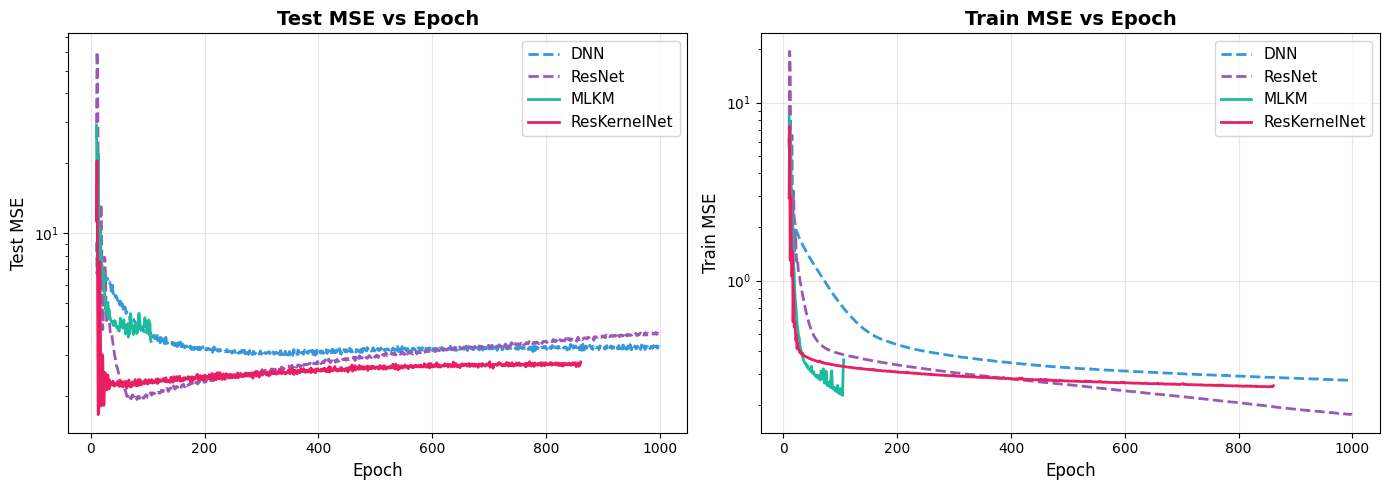


Figure saved as 'training_curves.png'

Epochs run: DNN=1000, ResNet=1000, MLKM=107, ResKernelNet=862


In [78]:
# Training Curves: Epoch vs MSE for DNN, ResNet, MLKM, ResKernelNet

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Define colors and styles
methods = {
    'DNN': {'train': dnn_trainloss, 'test': dnn_testloss, 'color': '#3498db', 'linestyle': '--'},
    'ResNet': {'train': res_trainloss, 'test': res_testloss, 'color': '#9b59b6', 'linestyle': '--'},
    'MLKM': {'train': mlkm_trainloss, 'test': mlkm_testloss, 'color': '#1abc9c', 'linestyle': '-'},
    'ResKernelNet': {'train': rkn_trainloss, 'test': rkn_testloss, 'color': '#e91e63', 'linestyle': '-'},
}

# Skip first N epochs to avoid initial large values
skip_epochs = 10

# Left plot: Test MSE
ax1 = axes[0]
for name, data in methods.items():
    epochs = range(skip_epochs, len(data['test']))
    ax1.plot(epochs, data['test'][skip_epochs:], 
             label=name, color=data['color'], linestyle=data['linestyle'], linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Test MSE', fontsize=12)
ax1.set_title('Test MSE vs Epoch', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# Right plot: Train MSE
ax2 = axes[1]
for name, data in methods.items():
    epochs = range(skip_epochs, len(data['train']))
    ax2.plot(epochs, data['train'][skip_epochs:], 
             label=name, color=data['color'], linestyle=data['linestyle'], linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Train MSE', fontsize=12)
ax2.set_title('Train MSE vs Epoch', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'training_curves.png'")
print(f"\nEpochs run: DNN={len(dnn_trainloss)}, ResNet={len(res_trainloss)}, MLKM={len(mlkm_trainloss)}, ResKernelNet={len(rkn_trainloss)}")


In [89]:
# ── Conformal Prediction for all neural methods (ACI) ────────────────────────
# SML2010 is time-series data: calibration (DATA-1 tail) and test (DATA-2)
# come from different time periods → distribution shift.
# Standard split conformal (fixed quantile) cannot guarantee coverage here.
# We use Adaptive Conformal Inference (ACI, Gibbs & Candès 2021) which adapts
# the quantile level online to maintain approximate target coverage despite drift.

def aci_conformal_net(net, device, X_cal, y_cal, X_te, y_te,
                      alpha=0.05, gamma=0.05):
    """
    Adaptive Conformal Inference for a PyTorch net.
    Adapts alpha_t at each test step based on observed coverage.
    Returns (final_coverage, avg_interval_length, q_hat_avg).
    """
    net.eval()
    with torch.no_grad():
        cal_preds = net(torch.from_numpy(X_cal).float().to(device)).squeeze().cpu().numpy()
        te_preds  = net(torch.from_numpy(X_te).float().to(device)).squeeze().cpu().numpy()

    cal_scores  = np.abs(y_cal - cal_preds)
    sorted_scores = np.sort(cal_scores)
    m = len(sorted_scores)

    alpha_t   = alpha
    coverages = []
    intervals = []

    for i in range(len(y_te)):
        alpha_t = np.clip(alpha_t, 0.001, 0.999)
        k = min(max(int(np.ceil((m + 1) * (1 - alpha_t))), 1), m)
        q_t = float(sorted_scores[k - 1])

        lower, upper = te_preds[i] - q_t, te_preds[i] + q_t
        intervals.append((lower, upper))

        covered = 1 if lower <= y_te[i] <= upper else 0
        coverages.append(covered)

        # ACI update: undershoot → widen (alpha_t ↓); overshoot → tighten (alpha_t ↑)
        alpha_t = alpha_t + gamma * (covered - (1 - alpha))

    final_cov = float(np.mean(coverages))
    avg_ivl   = float(np.mean([u - l for l, u in intervals]))
    avg_q     = avg_ivl / 2.0
    return final_cov, avg_ivl, avg_q


def aci_conformal_ridge(X_cal, y_cal, cal_preds, X_te, y_te, te_preds,
                        alpha=0.05, gamma=0.05):
    """ACI for a numpy predictor (RF+Ridge)."""
    cal_scores    = np.abs(y_cal - cal_preds)
    sorted_scores = np.sort(cal_scores)
    m = len(sorted_scores)

    alpha_t   = alpha
    coverages = []
    intervals = []

    for i in range(len(y_te)):
        alpha_t = np.clip(alpha_t, 0.001, 0.999)
        k = min(max(int(np.ceil((m + 1) * (1 - alpha_t))), 1), m)
        q_t = float(sorted_scores[k - 1])

        lower, upper = te_preds[i] - q_t, te_preds[i] + q_t
        intervals.append((lower, upper))

        covered = 1 if lower <= y_te[i] <= upper else 0
        coverages.append(covered)
        alpha_t = alpha_t + gamma * (covered - (1 - alpha))

    final_cov = float(np.mean(coverages))
    avg_ivl   = float(np.mean([u - l for l, u in intervals]))
    avg_q     = avg_ivl / 2.0
    return final_cov, avg_ivl, avg_q


TARGET_ALPHA = 0.05
ACI_GAMMA    = 0.05   # learning-rate; 0.05 is a good default for moderate drift

conformal_results = {}

# ── Neural net methods ────────────────────────────────────────────────────────
_net_methods = {
    'DNN':          (dnn_net,  dnn_device),
    'ResNet':       (res_net,  res_device),
    'MLKM':         (mlkm_net, mlkm_device),
    'ResKernelNet': (rkn_net,  rkn_device),
}

for name, (net, dev) in _net_methods.items():
    cov, ivl, q = aci_conformal_net(
        net, dev,
        calibration_x, calibration_y,
        test_x, test_y,
        alpha=TARGET_ALPHA, gamma=ACI_GAMMA
    )
    conformal_results[name] = {'coverage': cov, 'interval': ivl, 'q_hat': q}
    print(f'{name:15s}  coverage={cov:.3f}  avg_interval={ivl:.4f}')

# ── RF+Ridge ─────────────────────────────────────────────────────────────────
from sklearn.linear_model import Ridge
set_global_seed(7199)
_rff_cf   = RandomFourierFeature(d=train_x.shape[1], D=500, kernel='G', gamma=gamma_median)
_ridge_cf = Ridge(alpha=0.01)
_ridge_cf.fit(_rff_cf.transform(train_x), train_y)   # fit on train only

_cal_preds = _ridge_cf.predict(_rff_cf.transform(calibration_x))
_te_preds  = _ridge_cf.predict(_rff_cf.transform(test_x))

cov, ivl, q = aci_conformal_ridge(
    calibration_x, calibration_y, _cal_preds,
    test_x, test_y, _te_preds,
    alpha=TARGET_ALPHA, gamma=ACI_GAMMA
)
conformal_results['RF+Ridge'] = {'coverage': cov, 'interval': ivl, 'q_hat': q}
print(f'RF+Ridge        coverage={cov:.3f}  avg_interval={ivl:.4f}')

# ── DKL / DGP: mark as N/A ───────────────────────────────────────────────────
for name in ['DKL', 'DGP']:
    conformal_results[name] = {'coverage': float('nan'), 'interval': float('nan'), 'q_hat': float('nan')}
    print(f'{name:15s}  conformal N/A (GP posterior uncertainty)')


DNN              coverage=0.950  avg_interval=4.5693
ResNet           coverage=0.941  avg_interval=4.6152
MLKM             coverage=0.949  avg_interval=5.0719
ResKernelNet     coverage=0.948  avg_interval=4.3612
RF+Ridge        coverage=0.946  avg_interval=4.6975
DKL              conformal N/A (GP posterior uncertainty)
DGP              conformal N/A (GP posterior uncertainty)


/var/folders/z7/p968ccvd4d9c27v5n0y0qbyw0000gn/T/ipykernel_4150/462636501.py:74: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  result=torch.sqrt(torch.tensor([2.0/self.D])) * torch.cos( self.W @ x.T  + (self.b.reshape(-1,1) @ torch.ones(len(x)).reshape(1,-1)))
/var/folders/z7/p968ccvd4d9c27v5n0y0qbyw0000gn/T/ipykernel_4150/462636501.py:74: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  result=torch.sqrt(torch.tensor([2.0/self.D])) * torch.cos( self.W @ x.T  + (self.b.reshape(-1,1) @ torch.ones(len(x)).reshape(1,-1)))
/var/folders/z7/p968ccvd4d9c27v5n0y0qbyw0000gn/T/ipykernel_4150/462636501.py:74: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  result=torch.sqrt(torch.tensor([2.0/self.D])) * torch.cos( self.W @ x.T  + 

## Results: Comparison Table & Visualisation

In [92]:
# ── Comparison Table: all methods ────────────────────────────────────────────
import pandas as pd

# Collect all results
_rows = [
    {
        'Method':       'RF+Ridge',
        'Train MSE':    rf_train_mse,
        'Test MSE':     rf_test_mse,
        'Time (s)':     rf_time,
        'CPU Δ (MB)':   rf_delta_cpu_mb,
        'CPU Peak (MB)':rf_peak_cpu_mb,
        'Conf. Coverage': conformal_results['RF+Ridge']['coverage'],
        'Conf. Interval': conformal_results['RF+Ridge']['interval'],
    },
    {
        'Method':       'DNN',
        'Train MSE':    dnn_train_mse,
        'Test MSE':     dnn_test_mse,
        'Time (s)':     dnn_time,
        'CPU Δ (MB)':   dnn_delta_cpu_mb,
        'CPU Peak (MB)':dnn_peak_cpu_mb,
        'Conf. Coverage': conformal_results['DNN']['coverage'],
        'Conf. Interval': conformal_results['DNN']['interval'],
    },
    {
        'Method':       'ResNet',
        'Train MSE':    res_train_mse,
        'Test MSE':     res_test_mse,
        'Time (s)':     res_time,
        'CPU Δ (MB)':   res_delta_cpu,
        'CPU Peak (MB)':res_peak_cpu,
        'Conf. Coverage': conformal_results['ResNet']['coverage'],
        'Conf. Interval': conformal_results['ResNet']['interval'],
    },
    {
        'Method':       'DKL',
        'Train MSE':    dkl_train_mse,
        'Test MSE':     dkl_test_mse,
        'Time (s)':     dkl_time,
        'CPU Δ (MB)':   dkl_delta_cpu,
        'CPU Peak (MB)':dkl_peak_cpu,
        'Conf. Coverage': float('nan'),
        'Conf. Interval': float('nan'),
    },
    {
        'Method':       'DGP',
        'Train MSE':    dgp_train_mse,
        'Test MSE':     dgp_test_mse,
        'Time (s)':     dgp_time,
        'CPU Δ (MB)':   dgp_delta_cpu,
        'CPU Peak (MB)':dgp_peak_cpu,
        'Conf. Coverage': float('nan'),
        'Conf. Interval': float('nan'),
    },
    {
        'Method':       'MLKM',
        'Train MSE':    mlkm_train_mse,
        'Test MSE':     mlkm_test_mse,
        'Time (s)':     mlkm_time,
        'CPU Δ (MB)':   mlkm_delta_cpu,
        'CPU Peak (MB)':mlkm_peak_cpu,
        'Conf. Coverage': conformal_results['MLKM']['coverage'],
        'Conf. Interval': conformal_results['MLKM']['interval'],
    },
    {
        'Method':       'ResKernelNet',
        'Train MSE':    rkn_train_mse,
        'Test MSE':     rkn_test_mse,
        'Time (s)':     rkn_time,
        'CPU Δ (MB)':   rkn_delta_cpu,
        'CPU Peak (MB)':rkn_peak_cpu,
        'Conf. Coverage': conformal_results['ResKernelNet']['coverage'],
        'Conf. Interval': conformal_results['ResKernelNet']['interval'],
    },
]

results_df = pd.DataFrame(_rows).set_index('Method')

# Format for display
_fmt = {
    'Train MSE':     '{:.5f}',
    'Test MSE':      '{:.5f}',
    'Time (s)':      '{:.2f}',
    'CPU Δ (MB)':    '{:.1f}',
    'CPU Peak (MB)': '{:.1f}',
    'Conf. Coverage':'{:.3f}',
    'Conf. Interval':'{:.4f}',
}
print('=' * 85)
print('  SML2010 — Method Comparison  (HIDDEN=(32,64,16), D=64, per-layer gamma)')
print('=' * 85)
print(results_df.to_string(float_format=lambda x: f'{x:.5f}'))
print()

# Highlight best

best_test = results_df['Test MSE'].idxmin()
best_ivl  = results_df['Conf. Interval'].dropna().idxmin()
print(f'  Best Test MSE:       {best_test} ({results_df.loc[best_test,"Test MSE"]:.5f})')
print(f'  Shortest CI:         {best_ivl}  ({results_df.loc[best_ivl,"Conf. Interval"]:.4f})')

# Save
results_df.to_csv(os.path.join(RESULTS_DIR, 'comparison_table.csv'))
print(f'\nSaved → {RESULTS_DIR}/comparison_table.csv')


  SML2010 — Method Comparison  (HIDDEN=(32,64,16), D=64, per-layer gamma)
              Train MSE  Test MSE  Time (s)  CPU Δ (MB)  CPU Peak (MB)  Conf. Coverage  Conf. Interval
Method                                                                                                
RF+Ridge        0.87953   5.26417   1.83072     0.48438        1.85928         0.94610         4.69753
DNN             0.27444   3.24568  21.25071  -412.03125        0.37118         0.94975         4.56931
ResNet          0.17643   3.69535  25.79656   -18.54688        0.39065         0.94101         4.61518
DKL             0.09329   4.56477  16.02683    -3.07812        0.30759             NaN             NaN
DGP             0.13471   4.78836 369.17329  -215.64062        2.21875             NaN             NaN
MLKM            0.35842   3.42553   3.96368    -4.28125        0.54688         0.94902         5.07193
ResKernelNet    0.25622   2.79354  26.82562 -1053.35938        1.10938         0.94829         4.36120

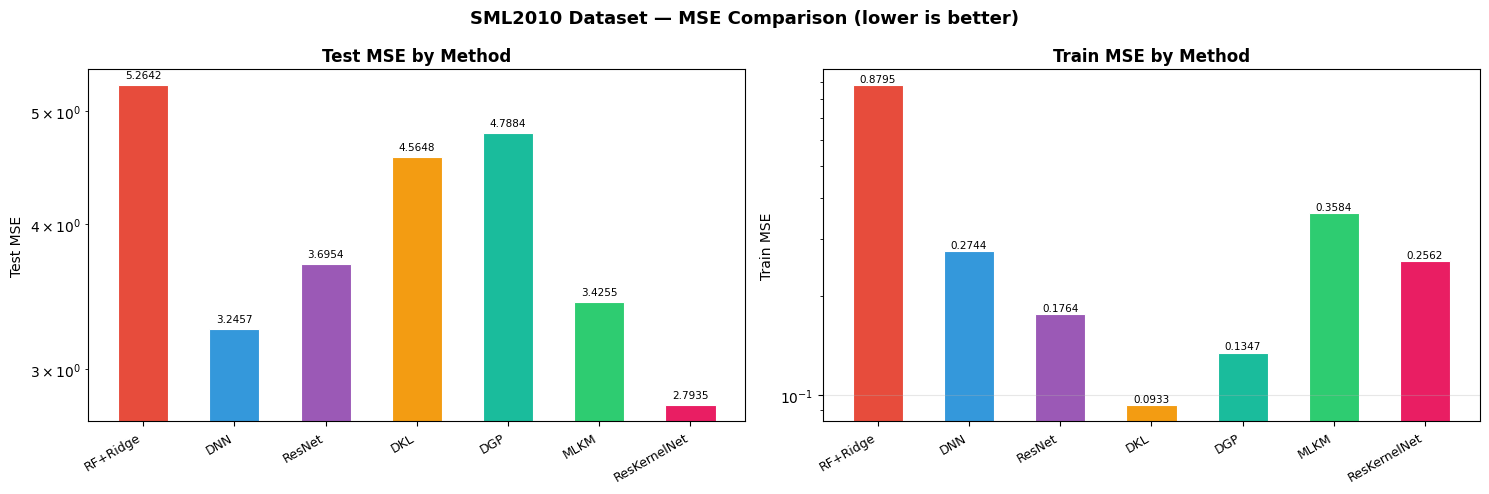

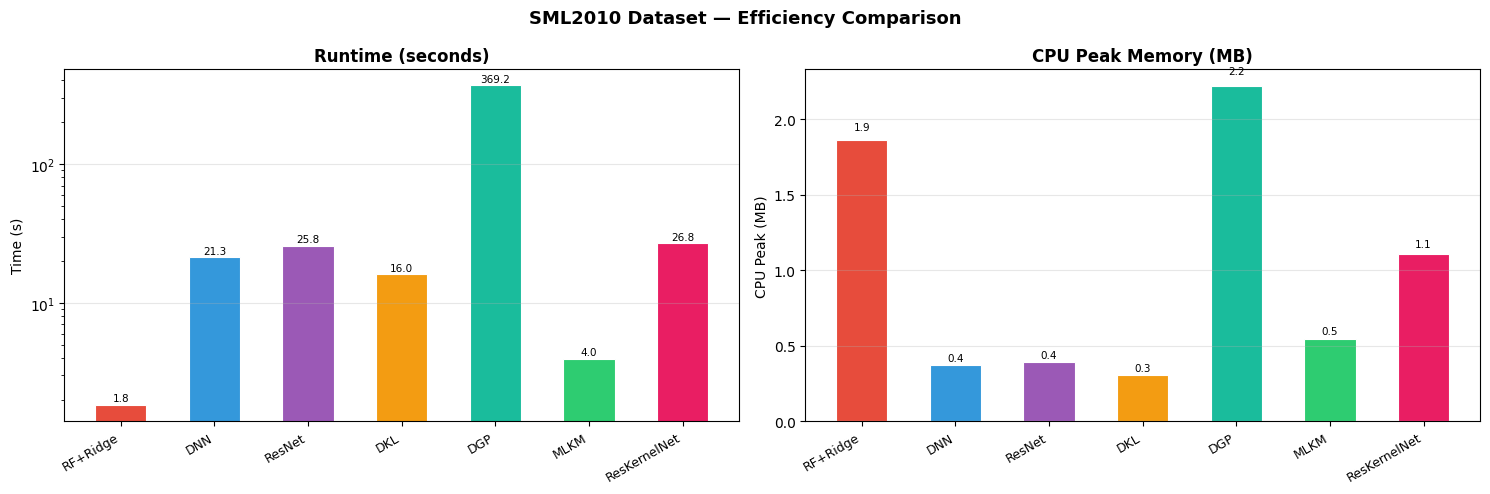

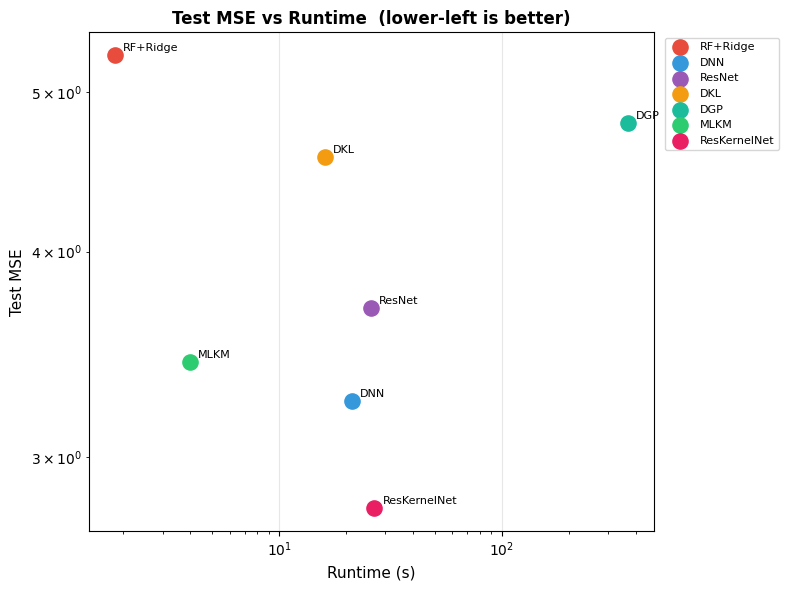

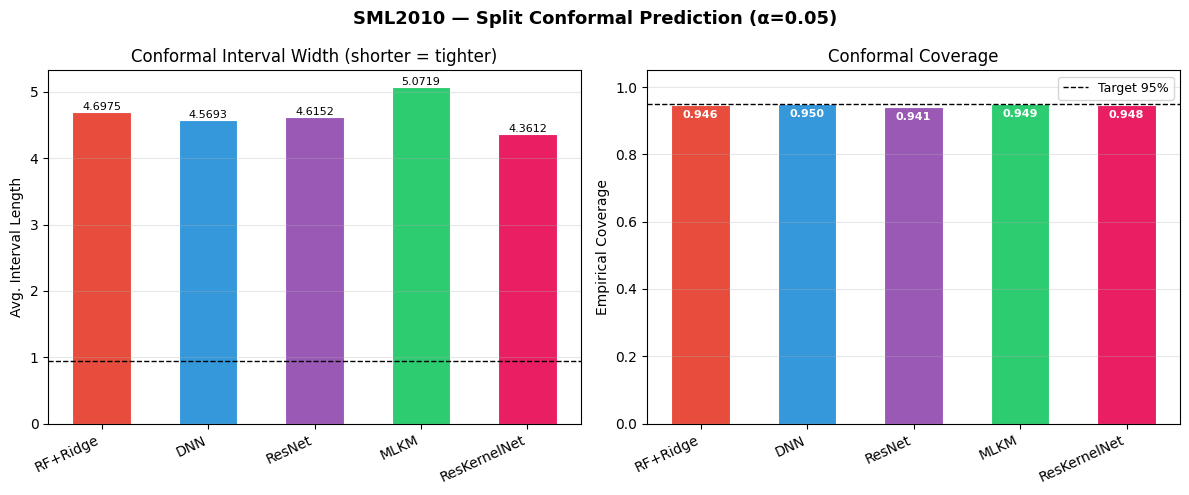

Saved all figures to sml_results_calib40/


In [91]:
# ── Result Visualisation ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

methods  = results_df.index.tolist()
colors   = ['#e74c3c','#3498db','#9b59b6','#f39c12','#1abc9c','#2ecc71','#e91e63']
x        = np.arange(len(methods))
bar_w    = 0.55

# ── Fig 1: Test MSE + Train MSE side by side ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, col, title in [
    (axes[0], 'Test MSE',  'Test MSE by Method'),
    (axes[1], 'Train MSE', 'Train MSE by Method'),
]:
    vals = results_df[col].values
    bars = ax.bar(x, vals, width=bar_w, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_xticks(x); ax.set_xticklabels(methods, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(col); ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_yscale('log')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{v:.4f}', ha='center', va='bottom', fontsize=7.5)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('SML2010 Dataset — MSE Comparison (lower is better)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig1_mse_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Fig 2: Runtime + CPU Peak Memory ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, col, title, logy in [
    (axes[0], 'Time (s)',      'Runtime (seconds)',       True),
    (axes[1], 'CPU Peak (MB)', 'CPU Peak Memory (MB)',    False),
]:
    vals = results_df[col].values
    bars = ax.bar(x, vals, width=bar_w, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_xticks(x); ax.set_xticklabels(methods, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(col); ax.set_title(title, fontsize=12, fontweight='bold')
    if logy: ax.set_yscale('log')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.03,
                f'{v:.1f}', ha='center', va='bottom', fontsize=7.5)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('SML2010 Dataset — Efficiency Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig2_efficiency.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Fig 3: Scatter — Test MSE vs Runtime ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for i, m in enumerate(methods):
    ax.scatter(results_df.loc[m,'Time (s)'], results_df.loc[m,'Test MSE'],
               color=colors[i], s=120, zorder=5, label=m)
    ax.annotate(m, (results_df.loc[m,'Time (s)'], results_df.loc[m,'Test MSE']),
                textcoords='offset points', xytext=(6, 3), fontsize=8)
ax.set_xlabel('Runtime (s)', fontsize=11); ax.set_ylabel('Test MSE', fontsize=11)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title('Test MSE vs Runtime  (lower-left is better)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig3_mse_vs_time.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Fig 4: Conformal Interval (methods that support it) ──────────────────────
_cf_df = results_df[['Conf. Coverage', 'Conf. Interval']].dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cf_methods = _cf_df.index.tolist()
cf_colors  = [colors[methods.index(m)] for m in cf_methods]
xc = np.arange(len(cf_methods))

axes[0].bar(xc, _cf_df['Conf. Interval'].values, width=bar_w,
            color=cf_colors, edgecolor='white', linewidth=0.8)
axes[0].axhline(0.95, color='k', ls='--', lw=1, label='Target 95%')
for v, xi in zip(_cf_df['Conf. Interval'].values, xc):
    axes[0].text(xi, v + 0.002, f'{v:.4f}', ha='center', va='bottom', fontsize=8)
axes[0].set_xticks(xc); axes[0].set_xticklabels(cf_methods, rotation=25, ha='right')
axes[0].set_ylabel('Avg. Interval Length'); axes[0].set_title('Conformal Interval Width (shorter = tighter)')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(xc, _cf_df['Conf. Coverage'].values, width=bar_w,
            color=cf_colors, edgecolor='white', linewidth=0.8)
axes[1].axhline(0.95, color='k', ls='--', lw=1, label='Target 95%')
for v, xi in zip(_cf_df['Conf. Coverage'].values, xc):
    axes[1].text(xi, v - 0.015, f'{v:.3f}', ha='center', va='top', fontsize=8, color='white', fontweight='bold')
axes[1].set_xticks(xc); axes[1].set_xticklabels(cf_methods, rotation=25, ha='right')
axes[1].set_ylabel('Empirical Coverage'); axes[1].set_title('Conformal Coverage')
axes[1].set_ylim(0, 1.05); axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('SML2010 — Split Conformal Prediction (α=0.05)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig4_conformal.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved all figures to {RESULTS_DIR}/')
